
ID & Profile Type                             | VALID/TOTAL  | P1(Edge) | P2(Mid)  | P3(Cen)  | MEAN
------------------------------------------------------------------------------------------------------------------------
(A1) U-Shape 11mm                             | 11/11        |    20.00 |    20.00 |    20.00 |  20.00
(A2) U-Shape 21mm                             | 1/21         |    20.00 |     0.00 |     0.00 |  20.00
(A3) U-Shape 31mm                             | 1/31         |    20.00 |     0.00 |     0.00 |  20.00
(B1) V-Shape 11mm                             | 9/11         |     0.00 |     8.00 |    20.00 |  11.11
(B2) V-Shape 21mm                             | 17/21        |     0.00 |     6.00 |    16.00 |   7.76
(B3) V-Shape 31mm                             | 22/31        |     0.00 |     1.33 |    10.67 |   4.30
(C1) Concave 11mm                             | 9/11         |     0.00 |    12.80 |    20.00 |  14.67
(C2) Concave 21mm                             | 17/21   

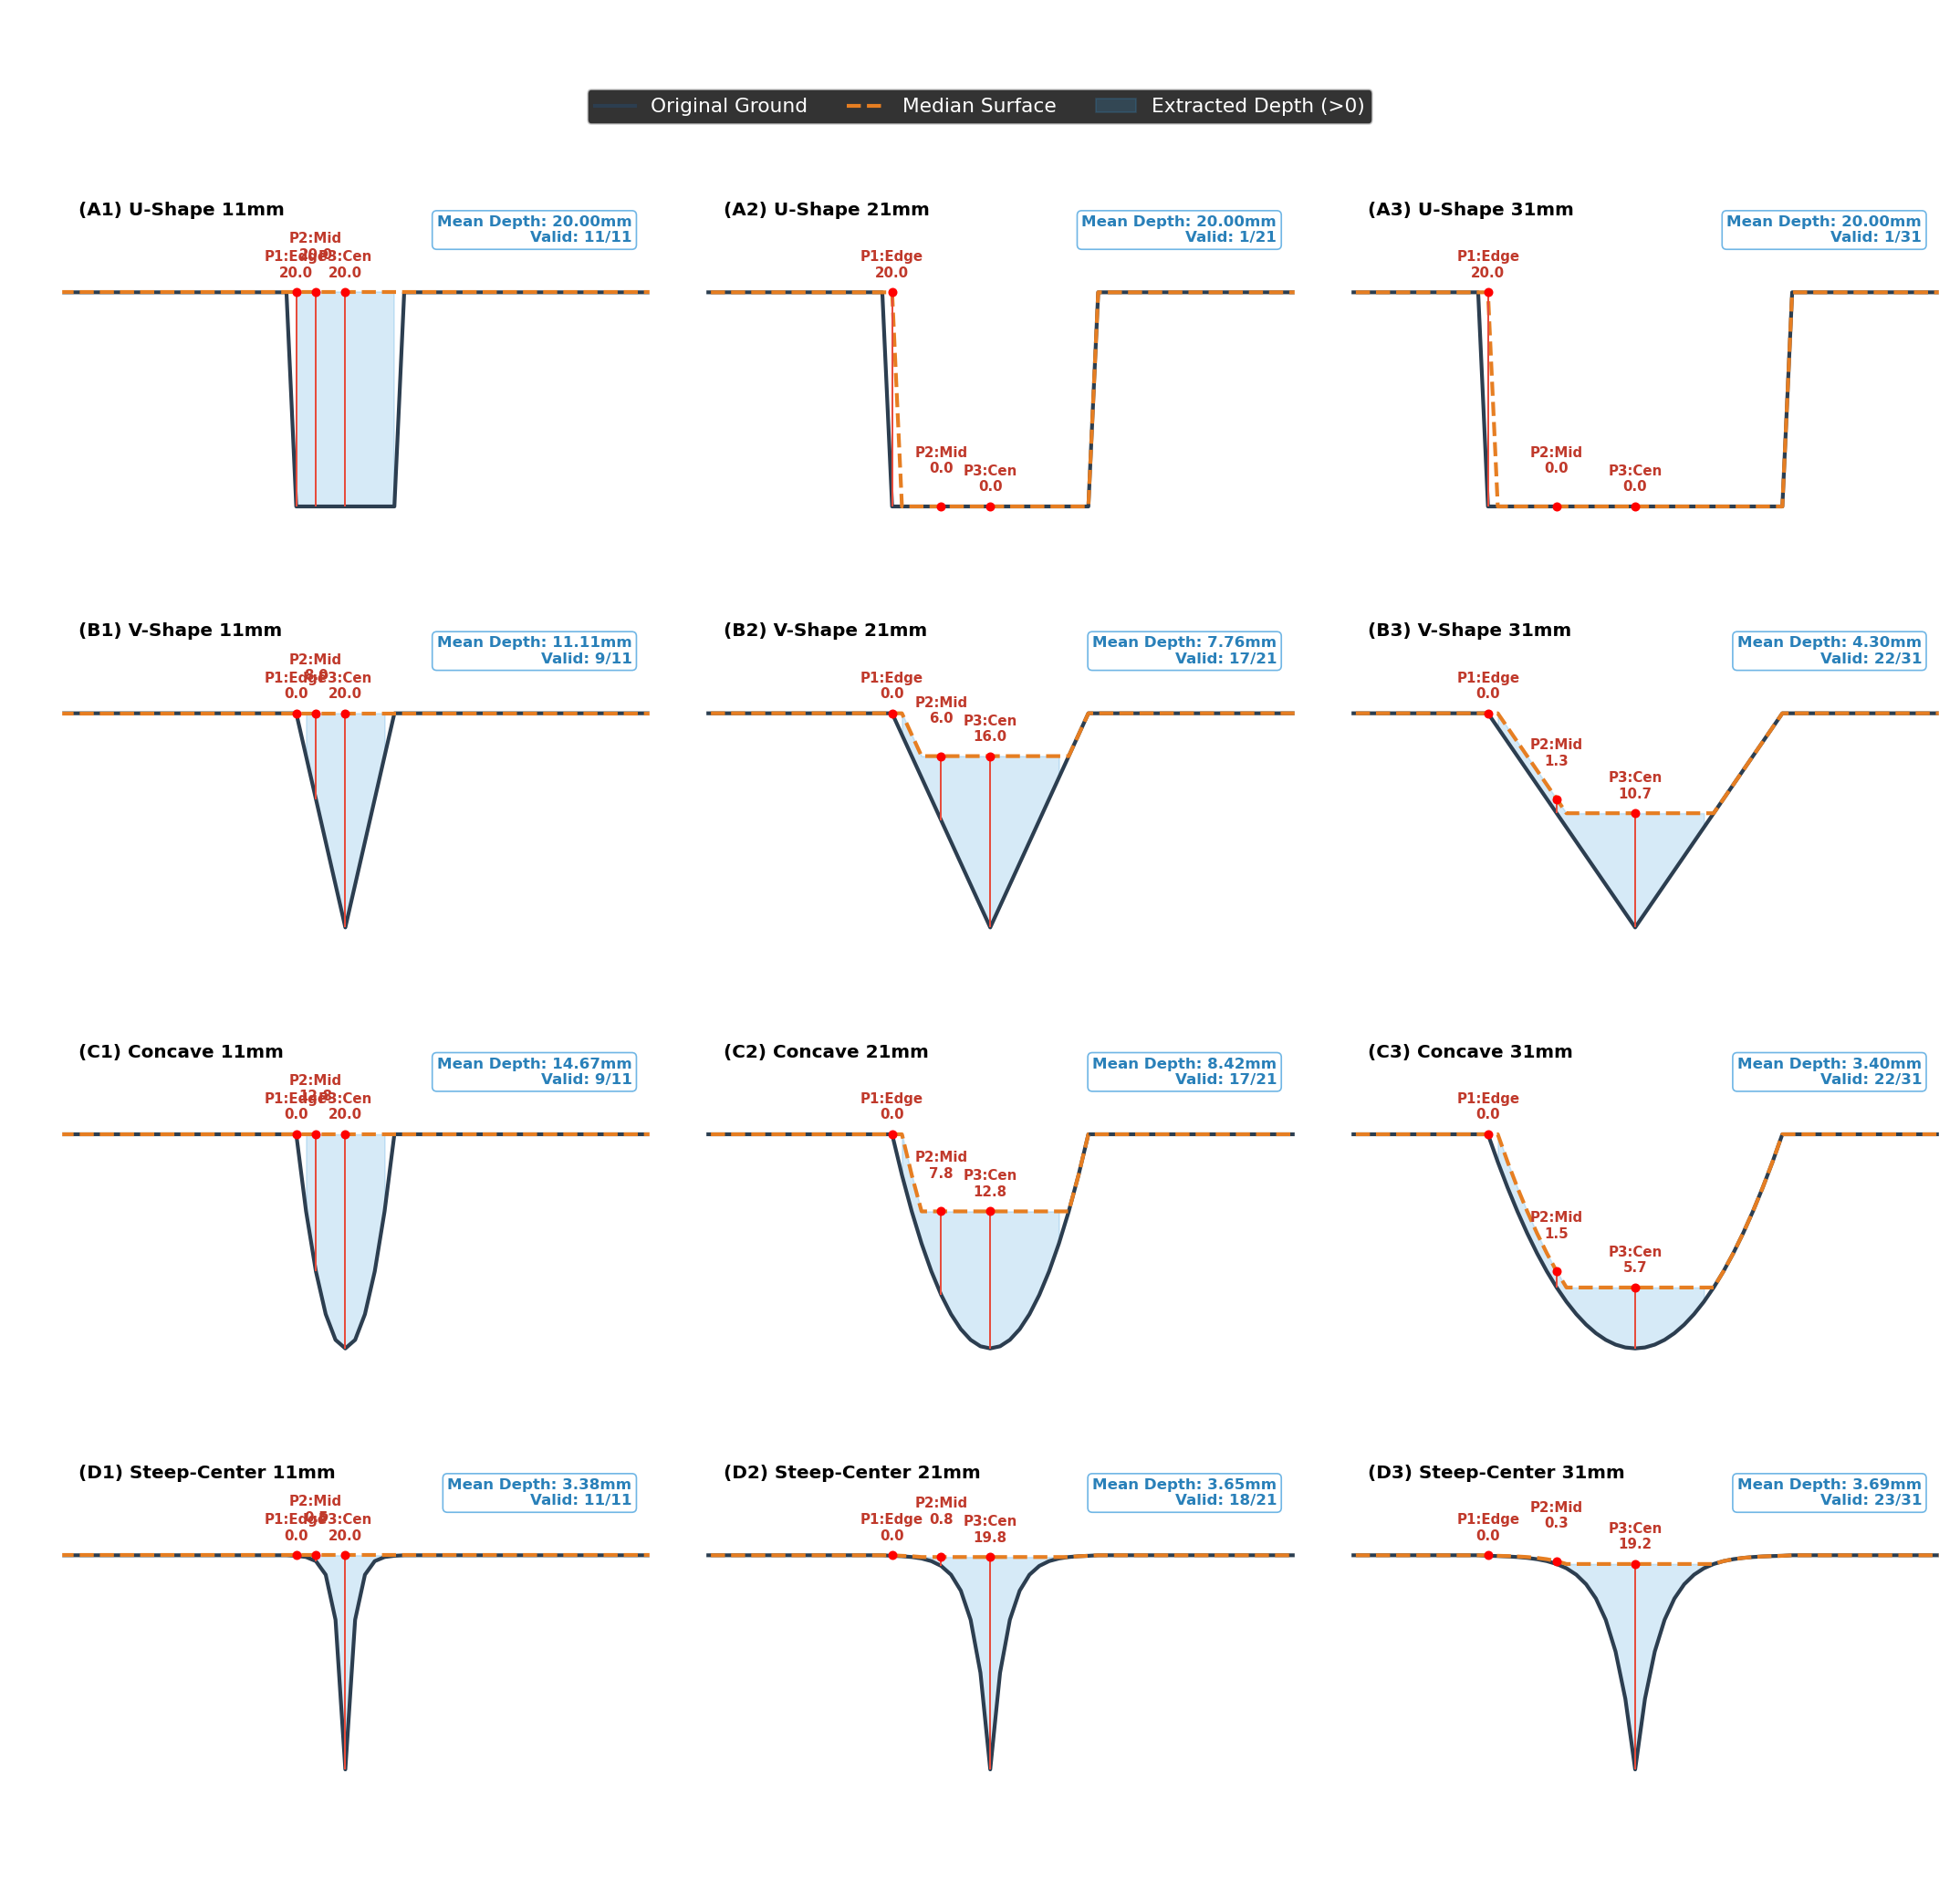

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
import pandas as pd
import os

# --- 1. 地形剖面生成函數 ---
def generate_profiles(width, max_depth=20.0, bg=50.0):
    length = 100 
    base = np.full(length, bg)
    start = (length - width) // 2
    end = start + width
    center_idx = start + width // 2
    
    # 3 個取樣點：P1(邊緣), P2(中點), P3(中心)
    pts_indices = [
        start, 
        start + (center_idx - start) // 2, 
        center_idx
    ]
    
    x = np.linspace(-1, 1, width)
    
    # 四種地形幾何模型
    u = base.copy(); u[start:end] = bg - max_depth
    v = base.copy(); v[start:end] = bg - (max_depth * (1 - np.abs(x)))
    concave = base.copy(); concave[start:end] = bg - (max_depth * (1 - x**2))
    steep = base.copy(); steep[start:end] = bg - (max_depth * np.exp(-6 * np.abs(x)))
        
    return start, end, pts_indices, {'U-Shape': u, 'V-Shape': v, 'Concave': concave, 'Steep-Center': steep}

# --- 2. 空間濾波分析 ---
def analyze_gap(width, window_size=30):
    start, end, pts_indices, dems = generate_profiles(width)
    results = {}
    for name, dem in dems.items():
        # 使用 constant 填充模擬 ArcGIS Pro 的對稱邊界處理
        filled = median_filter(dem, size=window_size, mode='constant', cval=50.0)
        diff = filled - dem
        
        # 僅針對縫隙區間內 (Diff > 0) 的有效點進行統計
        gap_data = diff[start:end]
        valid_mask = gap_data > 1e-3 
        
        if np.any(valid_mask):
            mean_v = np.mean(gap_data[valid_mask])
            calc_count = np.sum(valid_mask)
        else:
            mean_v = 0.0
            calc_count = 0
            
        results[name] = {
            'dem': dem, 'filled': filled, 'diff': diff,
            'diff_vals': [diff[idx] for idx in pts_indices],
            'mean_depth': mean_v, 'calc_count': calc_count
        }
    return pts_indices, results

# --- 3. 執行參數設定 (11, 21, 31 mm) ---
window = 30
widths = [11, 21, 31]
shapes = ['U-Shape', 'V-Shape', 'Concave', 'Steep-Center']
data_results = {w: analyze_gap(w, window) for w in widths}

# --- 4. 繪圖與 ID 標註 ---
fig, axes = plt.subplots(len(shapes), len(widths), figsize=(18, 18), facecolor='white', dpi=120)
fig.suptitle(f'DEM Gap Analysis (Window: {window}px) | Sampling: Edge, Mid, Center', 
             fontsize=24, fontweight='bold', y=0.98)

x_axis = np.arange(100)
table_data = [] # 儲存所有數據以便輸出雙表

for i, shape in enumerate(shapes):
    for j, width in enumerate(widths):
        ax = axes[i, j]
        pts, res = data_results[width]
        data = res[shape]
        
        # 精確生成 ID 標籤，例如 (A1) U-Shape 11mm
        id_tag = f"({chr(65+i)}{j+1})"
        full_label = f"{id_tag} {shape} {width}mm"
        
        # 1. 繪製 DEM 線條與有效區域陰影
        l_orig, = ax.plot(x_axis, data['dem'], color='#2c3e50', lw=2.5, label='Original Ground')
        l_fill, = ax.plot(x_axis, data['filled'], color='#e67e22', ls='--', lw=2.5, label='Median Surface')
        f_area = ax.fill_between(x_axis, data['filled'], data['dem'], 
                                 where=(data['diff'] > 1e-3), color='#3498db', alpha=0.2)

        # 2. 在圖中添加 ID 編號與標籤 (加粗顯示)
        ax.text(0.03, 0.92, full_label, transform=ax.transAxes, fontsize=12, fontweight='bold', color='black')
        
        # 3. 數據小標籤 (右上角)
        info_text = f"Mean Depth: {data['mean_depth']:.2f}mm\nValid: {data['calc_count']}/{width}"
        ax.text(0.97, 0.92, info_text, transform=ax.transAxes, fontsize=10, fontweight='bold', 
                color='#2980b9', ha='right', va='top', bbox=dict(boxstyle='round', fc='white', ec='#3498db', alpha=0.7))

        # 4. 取樣點標註 (P1, P2, P3)
        pt_names = ['P1:Edge', 'P2:Mid', 'P3:Cen']
        for idx, (pt_idx, val, name) in enumerate(zip(pts, data['diff_vals'], pt_names)):
            ax.vlines(pt_idx, data['dem'][pt_idx], data['filled'][pt_idx], color='#e74c3c', lw=1.2)
            ax.plot(pt_idx, data['filled'][pt_idx], 'ro', markersize=5)
            y_off = 10 if idx != 1 else 22
            ax.annotate(f"{name}\n{val:.1f}", xy=(pt_idx, data['filled'][pt_idx]), xytext=(0, y_off),
                        textcoords='offset points', ha='center', fontsize=9, fontweight='bold', color='#c0392b')

        ax.set_ylim(25, 60); ax.set_xlim(20, 80); ax.set_facecolor('white')
        if j == 0: ax.set_ylabel('Elevation (mm)')
        if i == len(shapes)-1: ax.set_xlabel('Distance (px)')
        
        # 收集數據
        table_data.append({
            'ID & Profile Type': full_label,
            'VALID/TOTAL': f"{data['calc_count']}/{width}",
            'P1(Edge)': data['diff_vals'][0],
            'P2(Mid)': data['diff_vals'][1],
            'P3(Cen)': data['diff_vals'][2],
            'MEAN': data['mean_depth']
        })

fig.legend([l_orig, l_fill, f_area], ['Original Ground', 'Median Surface', 'Extracted Depth (>0)'], 
           loc='upper center', bbox_to_anchor=(0.5, 0.945), ncol=3, frameon=True, fontsize=13)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig("dem_analysis_final_report.png", facecolor='white')

# --- 5. 分開輸出結果 (雙表邏輯) ---

# 輸出結果一：詳細資料表
print("\n" + "="*120)
print(f"{'ID & Profile Type':<45} | {'VALID/TOTAL':<12} | {'P1(Edge)':<8} | {'P2(Mid)':<8} | {'P3(Cen)':<8} | {'MEAN'}")
print("-" * 120)
for r in table_data:
    print(f"{r['ID & Profile Type']:<45} | {r['VALID/TOTAL']:<12} | {r['P1(Edge)']:>8.2f} | {r['P2(Mid)']:>8.2f} | {r['P3(Cen)']:>8.2f} | {r['MEAN']:>6.2f}")
print("="*120)

# 輸出結果二：Mean 深度排序排行榜
df_rank = pd.DataFrame(table_data)
df_sorted = df_rank.sort_values(by='MEAN', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print(f"{'RANK':<5} | {'ID & Profile Type':<45} | {'MEAN DEPTH':<15}")
print("-" * 80)
for i, row in df_sorted.iterrows():
    print(f"{i+1:<5} | {row['ID & Profile Type']:<45} | {row['MEAN']:>10.2f} mm")
print("="*80)

print(f"\n[Info] Visualization saved to: {os.path.abspath('dem_analysis_final_report.png')}")
plt.show()